# Data Mining
# Week 7
# Submitter - Himanshu Singh
# Dimensionality Reduction and Feature Selection


Download the labeled training dataset from this link: House Prices - Advanced Regression Techniques. 

Part 1: PCA and Variance Threshold in a Linear Regression



* Import the housing data as a data frame and ensure that the data is loaded properly.
* Drop the "Id" column and any features that are missing more than 40% of their values.
* For numerical columns, fill in any missing data with the median value.
* For categorical columns, fill in any missing data with the most common value (mode).
* Convert the categorical columns to dummy variables.
* Split the data into a training and test set, where the SalePrice column is the target.
* Run a linear regression and report the R2-value and RMSE on the test set.
* Fit and transform the training features with a PCA so that 90% of the variance is retained (see section 9.1 in the Machine Learning with Python Cookbook).
* How many features are in the PCA-transformed matrix?
* Transform but DO NOT fit the test features with the same PCA.
* Repeat step 7 with your PCA transformed data.
* Take your original training features (from step 6) and apply a min-max scaler to them.
* Find the min-max scaled features in your training set that have a variance above 0.1 (see Section 10.1 in the Machine Learning with Python Cookbook).
* Transform but DO NOT fit the test features with the same steps applied in steps 11 and 12.
* Repeat step 7 with the high variance data.
* Summarize your findings.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA                               
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
# Using a relative path for reproducibility
df = pd.read_csv('./Week7/house-prices-advanced-regression-techniques/train.csv')
#print(df.head()) # Displaying the first few rows to confirm data loading
#print(df.info()) # Basic statistics to understand the data

# 2. Initial Cleaning drop 'ID'
df = df.drop(columns=['Id'], errors='ignore')

# 2. Drop Columns with >40% Missing Values
missing_threshold = 0.40
missing_series = df.isnull().mean()
cols_to_drop = missing_series[missing_series > missing_threshold].index.tolist()
print(cols_to_drop) 


# Drop those columns
df_cleaned = df.drop(columns=cols_to_drop)
#print(df_cleaned.info())

# 3/4. Fill Missing Values with Median for Numerical and Mode for Categorical
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
    else:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())
# 5. Dummy Variables for Categorical Columns
df_final = pd.get_dummies(df_cleaned, drop_first=True)


# 6. Train-Test Split 
X = df_final.drop('SalePrice', axis=1)
y = df_final['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Run a linear regression and report the R2-value and RMSE on the test set.
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2_base = r2_score(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Base Linear Regression - R2: {r2_base:.4f}, RMSE: {rmse_base:.2f}")

# Standardize features before PCA
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled = scaler_pca.transform(X_test)


# 8. PCA to retain 90% variance
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_scaled)

# 9. Number of PCA features
num_pca_features = X_train_pca.shape[1]
print(f"PCA Features: {num_pca_features}")

# 10. Transform but DO NOT fit on test data
X_test_pca = pca.transform(X_test_scaled)


# 11. Linear Regression on PCA transformed data
model_pca = LinearRegression()
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
r2_pca = r2_score(y_test, y_pred_pca)
rmse_pca = np.sqrt(mean_squared_error(y_test, y_pred_pca))
print(f"PCA Linear Regression - R2: {r2_pca:.4f}, RMSE: {rmse_pca:.2f}")

# 12. Min-Max Scaler
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
# Transform but DO NOT fit the test features
X_test_minmax = scaler_minmax.transform(X_test)

# 13. Variance Threshold > 0.1
selector = VarianceThreshold(threshold=0.1)
X_train_high_var = selector.fit_transform(X_train_minmax)
# 14. Transform but DO NOT fit the test features
X_test_high_var = selector.transform(X_test_minmax)
num_var_features = X_train_high_var.shape[1]


# 15. Repeat Step 7 (Linear Regression)
model = LinearRegression()
model.fit(X_train_high_var, y_train)
y_pred = model.predict(X_test_high_var)

r2_val = r2_score(y_test, y_pred)
rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2-value: {r2_val:.4f}")
print(f"RMSE: {rmse_val:.2f}")
print(f"High Variance Features: {num_var_features}")
print(f"Original number of features after dummy conversion: {X.shape[1]}")

# Data Preprocessing
# Cleaning: The "Id" column was removed. Columns missing more than 40% of their values (like Alley, MasVnrType, FireplaceQu, PoolQC
# , Fence, and MiscFeature) were dropped.
# Imputation: Missing numerical values were filled with the median, and categorical values were filled with the mode.
# Transformation: Categorical variables were converted into dummy variables, resulting in a total of 229 features.
# Splitting: The data was split into training (80%) and test (20%) sets using SalePrice as the target.

# Baseline Model Performance
# A standard linear regression was performed on the original preprocessed dataset.
# R^2 Value: 0.6478. 
# RMSE: 51,973.14

# Principal Component Analysis (PCA) Features were standardized and transformed using PCA to retain 90% of the variance.
# Number of features in PCA-transformed matrix: 127
# R^2 Value (PCA): 0.8409
# RMSE (PCA): 34,938.50
# The PCA model significantly outperformed the baseline, likely by reducing noise and multi-collinearity within the high-dimensional dummy-variable space.

# Variance Thresholding
# The original features were scaled using a Min-Max Scaler, and only features with a variance greater than 0.1 were retained.
# Number of high-variance features: 40
# R^2 Value (High Variance): 0.6481
# RMSE (High Variance): 51,952.01
# By focusing only on high-variance features, the feature set was aggressively reduced to just 40 columns while maintaining a performance level 
# almost identical to the full baseline model.

# Principal Component Analysis (PCA) significantly improved the model's accuracy. By reducing 229 correlated features into 
# 127 principal components, the model was able to capture the "signal" of house value more effectively than raw data, 
# reducing the prediction error by roughly 17,000 dollars. The Variance Threshold method proved that most of the 229 original 
# features were redundant. It achieved the same performance as the baseline model while using only 17% of the features (40 features).
# For maximum accuracy in house price prediction, PCA is the most effective approach. 
# For model simplicity and speed, Variance Thresholding is preferred as it maintains performance while drastically reducing data complexity.




['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
Base Linear Regression - R2: 0.6478, RMSE: 51973.14
PCA Features: 127
PCA Linear Regression - R2: 0.8409, RMSE: 34938.50
R2-value: 0.6481
RMSE: 51952.01
High Variance Features: 40
Original number of features after dummy conversion: 229


Download the data from this link Mushroom Classification. Based on several categorical features, you will predict whether or not a mushroom is edible or poisonous.

* Import the data as a data frame and ensure it is loaded correctly.
* Convert the categorical features (all of them) to dummy variables.
* Split the data into a training and test set.
* Fit a decision tree classifier on the training set.
* Report the accuracy and create a confusion matrix for the model prediction on the test set.
* Create a visualization of the decision tree.
* Use a χ2-statistic selector to pick the five best features for this data (see section 10.4 of the Machine Learning with Python Cookbook).
* Which five features were selected in step 7? Hint: Use the get_support function.
* Repeat steps 4 and 5 with the five best features selected in step 7.
* Summarize your findings.


Full Model Accuracy: 1.0
Full Model Confusion Matrix:
[[843   0]
 [  0 782]]


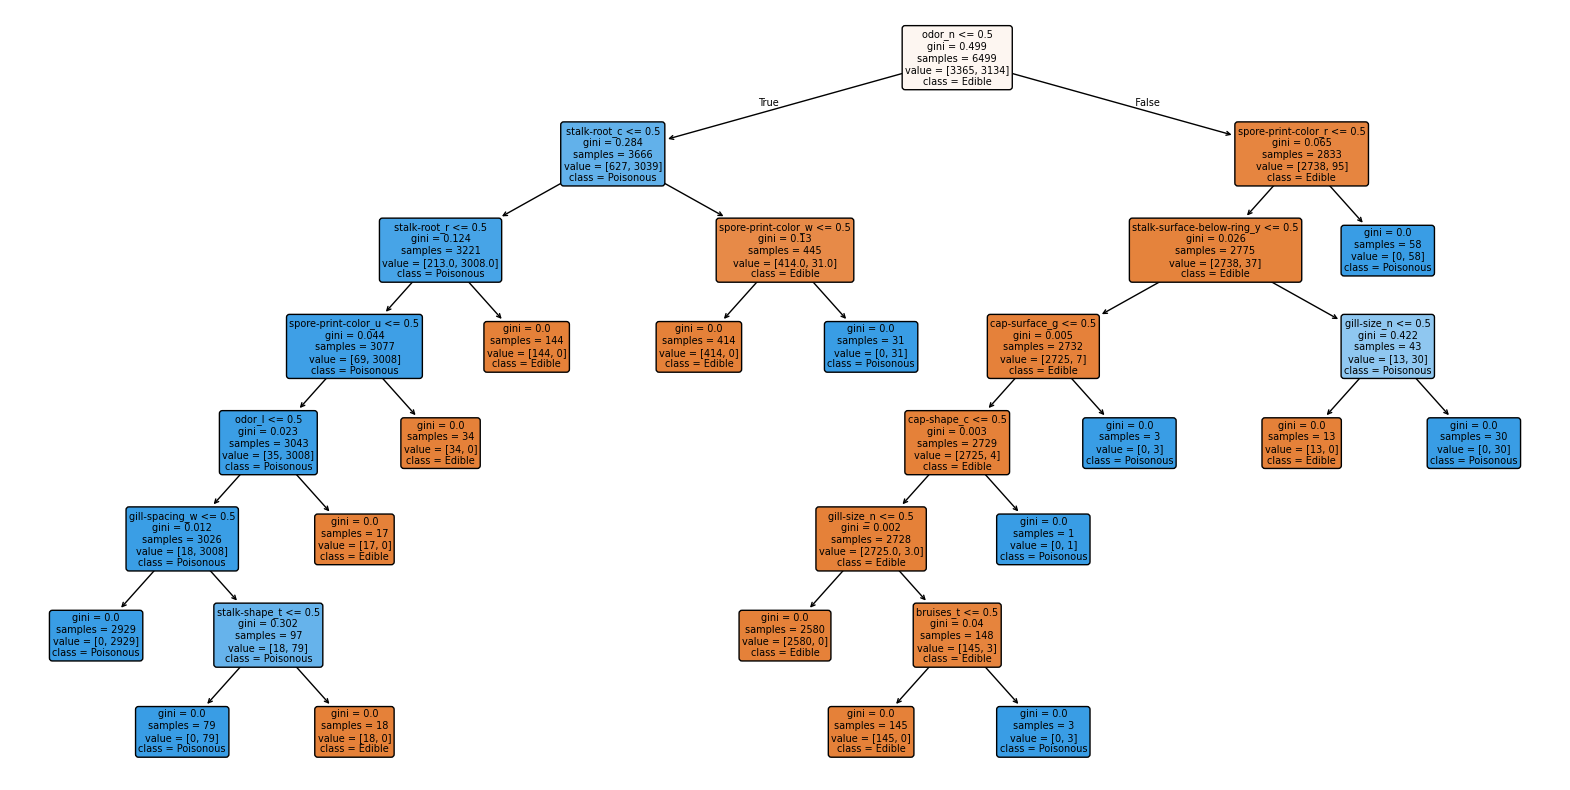

Original number of features: 95
Number of features after SelectKBest: 5
Selected Features: ['odor_f', 'odor_n', 'gill-size_n', 'stalk-surface-above-ring_k', 'stalk-surface-below-ring_k']
K-Best Model Accuracy: 0.9735384615384616
K-Best Model Confusion Matrix:
[[816  27]
 [ 16 766]]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, chi2

# 1. Import the data
df = pd.read_csv('week7/mushrooms.csv')
#print(df.head()) # Displaying the first few rows to confirm data loading
#print(df.info())   # Basic statistics to understand the data

# 2. Convert categorical features to dummy variables
# The target variable 'class' needs to be separated first
X = df.drop('class', axis=1)
y = df['class'].map({'e': 0, 'p': 1}) # e=edible, p=poisonous


X_dummies = pd.get_dummies(X, drop_first=True)

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y, test_size=0.2, random_state=42)

# 4. Fit a decision tree classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 5. Report accuracy and confusion matrix
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Full Model Accuracy: {accuracy}")
print(f"Full Model Confusion Matrix:\n{conf_matrix}")

# 6. Visualization of the decision tree 
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X_dummies.columns, class_names=['Edible', 'Poisonous'], filled=True, rounded=True)
plt.show() # Display the plot in interactive environments
plt.savefig('decision_tree.png')
plt.close()

# 7. Use chi2 selector for 5 best features
selector = SelectKBest(chi2, k=5)
X_train_kbest = selector.fit_transform(X_train, y_train)
X_test_kbest = selector.transform(X_test)
print(f"Original number of features: {X_dummies.shape[1]}")
print(f"Number of features after SelectKBest: {X_train_kbest.shape[1]}")

# 8. Identify the 5 features
selected_features = X_dummies.columns[selector.get_support()].tolist()
print(f"Selected Features: {selected_features}")    

# 9. Repeat steps 4 and 5 with 5 best features
dt_model_kbest = DecisionTreeClassifier(random_state=42)
dt_model_kbest.fit(X_train_kbest, y_train)

y_pred_kbest = dt_model_kbest.predict(X_test_kbest)
accuracy_kbest = accuracy_score(y_test, y_pred_kbest)
conf_matrix_kbest = confusion_matrix(y_test, y_pred_kbest)


print(f"K-Best Model Accuracy: {accuracy_kbest}")
print(f"K-Best Model Confusion Matrix:\n{conf_matrix_kbest}")


# Full Model Performance
# A Decision Tree was trained on the complete set of dummy variables derived from the categorical features.
# Accuracy: 1.0 (100%)
# Confusion Matrix: 
# True Edible: 843
# True Poisonous: 782
# False Positives/Negatives: 0

# Decision Tree Visualization
# The decision tree reached 100% accuracy quickly, as certain features (like odor) are incredibly strong indicators for this dataset.

# Using the Chi-Squared selector, the following five features were identified as the strongest predictors:
# odor_f 
# odor_n 
# gill-size_n 
# stalk-surface-above-ring_k 
# stalk-surface-below-ring_k 

# K-Best Model Performance (5 Features)
# Repeating the process with only these five features yielded the following:
# Accuracy: 0.9735 (97.35%)
# Confusion Matrix:True Edible: 816
# True Poisonous: 766
# False Negatives (Poisonous predicted as Edible): 16
# False Positives: 27

# This simplified model produced 16 False Negatives (classifying poisonous mushrooms as edible). While feature selection  (K-Best)
# helps create simpler, more efficient models, this problem proves that simplification can be dangerous. 
# In high-stakes scenarios like mushroom foraging, the Full Model is necessary because the last 3% of accuracy provides the critical 
# difference between a safe meal and a fatal mistake. The results highlight that odor is the single most important indicator, 
# but not sufficient on its own for 100% safety.